# 🏗️ Crack Detection, Quantification & Maintenance System
### Using CNN with Transfer Learning (MobileNetV2)
**Civil Engineering AI Project** | TensorFlow/Keras + OpenCV + Gradio

**Standards Referenced:**
- IS 456:2000 — Plain and Reinforced Concrete Code of Practice
- IS 13935:2009 — Repair and Seismic Strengthening of Buildings

## ✅ STEP 0 — Install Dependencies

In [1]:
!pip install gradio scikit-image -q
import os, cv2, json, time, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from skimage import morphology, measure
warnings.filterwarnings('ignore')

print('✅ All libraries loaded!')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

2026-04-06 01:38:59.146943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775439539.369561      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775439539.436517      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775439539.940485      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775439539.940523      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775439539.940525      55 computation_placer.cc:177] computation placer alr

✅ All libraries loaded!
TensorFlow: 2.19.0
GPU Available: True


## ⚙️ STEP 1 — Config

In [2]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-4
BASE_DIR    = '/kaggle/input/datasets/arunrk7/surface-crack-detection'
MODEL_PATH  = '/kaggle/working/best_crack_model.keras'

print('Config set!')
print(f'Dataset path: {BASE_DIR}')
print(f'Exists: {os.path.exists(BASE_DIR)}')
print(f'Contents: {os.listdir(BASE_DIR)}')

Config set!
Dataset path: /kaggle/input/datasets/arunrk7/surface-crack-detection
Exists: True
Contents: ['Negative', 'Positive']


## 📂 STEP 2 — Load Dataset

In [3]:
# Find Positive (crack) and Negative (no crack) folders
all_items = os.listdir(BASE_DIR)
print('Dataset contents:', all_items)

# Auto detect folders
positive_dir = None
negative_dir = None

for item in all_items:
    item_lower = item.lower()
    full_path = os.path.join(BASE_DIR, item)
    if os.path.isdir(full_path):
        if 'positive' in item_lower or 'crack' in item_lower:
            positive_dir = full_path
        elif 'negative' in item_lower or 'no' in item_lower:
            negative_dir = full_path

print(f'Crack images dir: {positive_dir}')
print(f'No crack images dir: {negative_dir}')

pos_count = len(os.listdir(positive_dir)) if positive_dir else 0
neg_count = len(os.listdir(negative_dir)) if negative_dir else 0
print(f'Crack images: {pos_count}')
print(f'No Crack images: {neg_count}')
print(f'Total: {pos_count + neg_count}')

Dataset contents: ['Negative', 'Positive']
Crack images dir: /kaggle/input/datasets/arunrk7/surface-crack-detection/Positive
No crack images dir: /kaggle/input/datasets/arunrk7/surface-crack-detection/Negative
Crack images: 20000
No Crack images: 20000
Total: 40000


## 🔀 STEP 3 — Prepare Train/Val/Test Split

In [4]:
import random
from sklearn.model_selection import train_test_split

# Get all image paths with labels
all_images = []
all_labels = []

for img_name in os.listdir(positive_dir):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        all_images.append(os.path.join(positive_dir, img_name))
        all_labels.append(1)  # 1 = crack

for img_name in os.listdir(negative_dir):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        all_images.append(os.path.join(negative_dir, img_name))
        all_labels.append(0)  # 0 = no crack

# Split: 70% train, 20% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(all_images, all_labels, test_size=0.3, random_state=42, stratify=all_labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.33, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# Create dataset directories
for split in ['train', 'val', 'test']:
    for cls in ['crack', 'no_crack']:
        os.makedirs(f'/kaggle/working/dataset/{split}/{cls}', exist_ok=True)

def copy_images(paths, labels, split):
    for path, label in zip(paths, labels):
        cls = 'crack' if label == 1 else 'no_crack'
        dst = f'/kaggle/working/dataset/{split}/{cls}/{os.path.basename(path)}'
        shutil.copy2(path, dst)

copy_images(X_train, y_train, 'train')
copy_images(X_val, y_val, 'val')
copy_images(X_test, y_test, 'test')
print('✅ Dataset split complete!')

Train: 28000 | Val: 8040 | Test: 3960
✅ Dataset split complete!


## 🖼️ STEP 4 — Data Augmentation & Generators

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/kaggle/working/dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    '/kaggle/working/dataset/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = val_datagen.flow_from_directory(
    '/kaggle/working/dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f'Class indices: {train_gen.class_indices}')
print('✅ Data generators ready!')

Found 28000 images belonging to 2 classes.
Found 8040 images belonging to 2 classes.
Found 3960 images belonging to 2 classes.
Class indices: {'crack': 0, 'no_crack': 1}
✅ Data generators ready!


## 🧠 STEP 5 — Build MobileNetV2 Model

In [6]:
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print(f'Total params: {model.count_params():,}')
print('✅ Model built!')

I0000 00:00:1775439942.890777      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775439942.896852      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params: 2,602,433
✅ Model built!


## 🚀 STEP 6 — Train Phase 1 (Frozen Backbone)

In [7]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss'),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy')
]

print('🚀 Phase 1 Training — Frozen backbone...')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)
print('✅ Phase 1 complete!')

🚀 Phase 1 Training — Frozen backbone...
Epoch 1/15


I0000 00:00:1775439951.369798     153 service.cc:152] XLA service 0x7b0e68144350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775439951.369841     153 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775439951.369847     153 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775439952.519776     153 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-06 01:46:01.554067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 01:46:01.691472: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1775439964.126710     153 device_co

875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9551 - loss: 0.1129 - precision: 0.9659 - recall: 0.9411

2026-04-06 01:51:32.089235: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 01:51:32.239690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 01:51:32.375892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


875/875 ━━━━━━━━━━━━━━━━━━━━ 349s 378ms/step - accuracy: 0.9551 - loss: 0.1128 - precision: 0.9660 - recall: 0.9412 - val_accuracy: 0.9966 - val_loss: 0.0112 - val_precision: 0.9985 - val_recall: 0.9948 - learning_rate: 1.0000e-04
Epoch 2/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 314s 359ms/step - accuracy: 0.9959 - loss: 0.0137 - precision: 0.9963 - recall: 0.9955 - val_accuracy: 0.9976 - val_loss: 0.0092 - val_precision: 0.9965 - val_recall: 0.9988 - learning_rate: 1.0000e-04
Epoch 3/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 313s 358ms/step - accuracy: 0.9960 - loss: 0.0125 - precision: 0.9968 - recall: 0.9953 - val_accuracy: 0.9976 - val_loss: 0.0086 - val_precision: 0.9983 - val_recall: 0.9970 - learning_rate: 1.0000e-04
Epoch 4/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 313s 357ms/step - accuracy: 0.9970 - loss: 0.0099 - precision: 0.9973 - recall: 0.9967 - val_accuracy: 0.9979 - val_loss: 0.0086 - val_precision: 0.9983 - val_recall: 0.9975 - learning_rate: 1.0000e-04
Epoch 5/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 315

## 🔥 STEP 7 — Train Phase 2 (Fine-tuning)

In [8]:
# Unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print('🔥 Phase 2 Training — Fine-tuning...')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
print('✅ Phase 2 complete!')
print(f'Model saved to: {MODEL_PATH}')

🔥 Phase 2 Training — Fine-tuning...
Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 338s 368ms/step - accuracy: 0.9613 - loss: 0.1064 - precision_1: 0.9956 - recall_1: 0.9253 - val_accuracy: 0.9951 - val_loss: 0.0142 - val_precision_1: 0.9909 - val_recall_1: 0.9995 - learning_rate: 1.0000e-05
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 316s 361ms/step - accuracy: 0.9955 - loss: 0.0148 - precision_1: 0.9956 - recall_1: 0.9953 - val_accuracy: 0.9968 - val_loss: 0.0109 - val_precision_1: 0.9941 - val_recall_1: 0.9995 - learning_rate: 1.0000e-05
Epoch 3/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 317s 363ms/step - accuracy: 0.9957 - loss: 0.0120 - precision_1: 0.9946 - recall_1: 0.9970 - val_accuracy: 0.9981 - val_loss: 0.0076 - val_precision_1: 0.9965 - val_recall_1: 0.9998 - learning_rate: 1.0000e-05
Epoch 4/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 315s 360ms/step - accuracy: 0.9972 - loss: 0.0083 - precision_1: 0.9974 - recall_1: 0.9970 - val_accuracy: 0.9991 - val_loss: 0.0052 - val_precision_1: 0.9988 - val_recall_1:

## 📊 STEP 8 — Training Curves

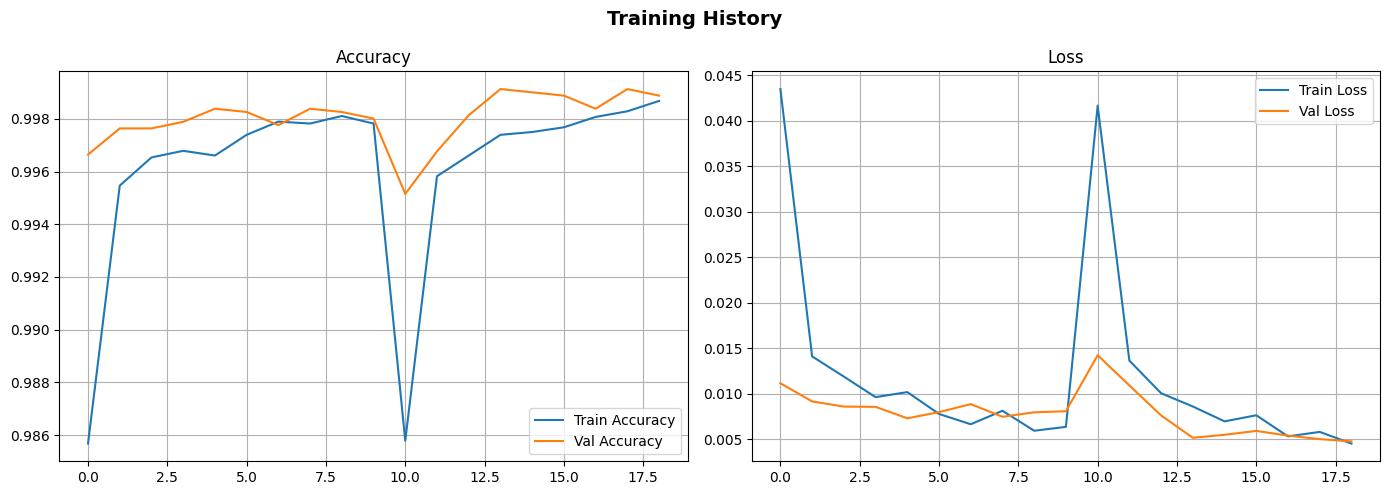

✅ Training curves saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine histories
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

axes[0].plot(acc, label='Train Accuracy')
axes[0].plot(val_acc, label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(loss, label='Train Loss')
axes[1].plot(val_loss, label='Val Loss')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=100)
plt.show()
print('✅ Training curves saved!')

## 🧪 STEP 9 — Test Set Evaluation

123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9983 - loss: 0.0053 - precision_1: 0.4972 - recall_1: 0.5035

2026-04-06 03:26:55.219056: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 03:26:55.356745: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


124/124 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.9983 - loss: 0.0053 - precision_1: 0.5053 - recall_1: 0.5115

📈 TEST RESULTS:
  Accuracy  : 0.9990
  Precision : 0.9985
  Recall    : 0.9995
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step


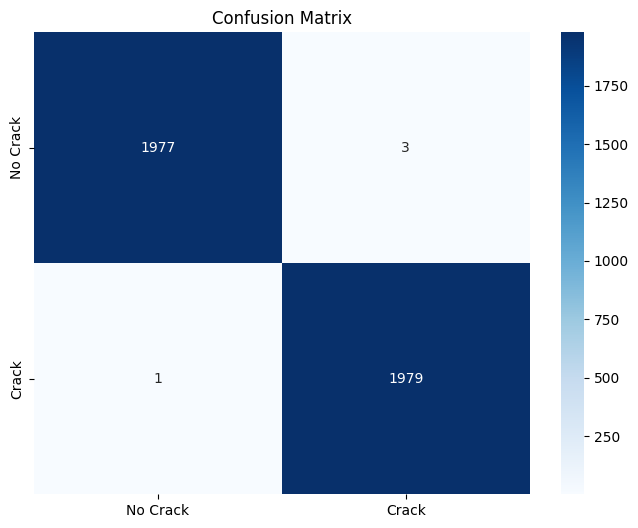


📋 Classification Report:
              precision    recall  f1-score   support

    No Crack       1.00      1.00      1.00      1980
       Crack       1.00      1.00      1.00      1980

    accuracy                           1.00      3960
   macro avg       1.00      1.00      1.00      3960
weighted avg       1.00      1.00      1.00      3960



In [10]:
best_model = keras.models.load_model(MODEL_PATH)

results = best_model.evaluate(test_gen, verbose=1)
print(f'\n📈 TEST RESULTS:')
print(f'  Accuracy  : {results[1]:.4f}')
print(f'  Precision : {results[2]:.4f}')
print(f'  Recall    : {results[3]:.4f}')

# Confusion matrix
y_pred = (best_model.predict(test_gen) > 0.5).astype(int).flatten()
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Crack', 'Crack'],
            yticklabels=['No Crack', 'Crack'])
plt.title('Confusion Matrix')
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=100)
plt.show()

print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=['No Crack', 'Crack']))

## 🔍 STEP 10 — Crack Analysis Function

In [14]:
def analyze_crack(image_path, model):
    """Full crack analysis pipeline"""
    
    # Load and preprocess
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    img_norm = img_resized / 255.0
    img_batch = np.expand_dims(img_norm, axis=0)
    
    # Predict
    start = time.time()
    pred = model.predict(img_batch, verbose=0)[0][0]
    infer_time = (time.time() - start) * 1000
    
    is_crack = pred < 0.5
    confidence = (1 - pred) if is_crack else pred
    
    result = {
        'status': 'CRACK DETECTED' if is_crack else 'NO CRACK',
        'confidence': float(confidence),
        'infer_time': infer_time
    }
    
    if is_crack:
        # Crack quantification using OpenCV
        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        kernel = np.ones((3,3), np.uint8)
        cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
        
        # Skeleton analysis
        skeleton = morphology.skeletonize(cleaned > 0)
        crack_pixels = np.sum(skeleton)
        total_pixels = skeleton.size
        crack_ratio = crack_pixels / total_pixels * 100
        
        # Severity score
        severity = min(100, crack_ratio * 10)
        
        if severity < 20:
            severity_level = 'MINOR'
            urgency = 'Low Priority — Monitor'
            repair = ['Surface sealing', 'Epoxy injection']
        elif severity < 50:
            severity_level = 'MODERATE'
            urgency = 'Medium Priority — Repair Soon'
            repair = ['Concrete patching', 'Crack injection', 'Surface treatment']
        else:
            severity_level = 'SEVERE'
            urgency = 'High Priority — Urgent Repair'
            repair = ['Immediate load reduction', 'Concrete stitching with reinforcement bars', 'Grouting under pressure']
        
        result.update({
            'severity': severity,
            'severity_level': severity_level,
            'urgency': urgency,
            'repair_methods': repair,
            'crack_pixels': int(crack_pixels),
            'crack_ratio': crack_ratio,
            'binary_mask': cleaned,
            'skeleton': skeleton
        })
    
    result['original'] = img_resized
    return result

print('✅ Analysis function ready!')

✅ Analysis function ready!


## 🖼️ STEP 11 — Test on Sample Images


--- Image 1 ---
  Status     : CRACK DETECTED
  Confidence : 100.00%
  Severity   : 5.2/100 (MINOR)
  Urgency    : Low Priority — Monitor

--- Image 2 ---
  Status     : CRACK DETECTED
  Confidence : 100.00%
  Severity   : 7.1/100 (MINOR)
  Urgency    : Low Priority — Monitor

--- Image 3 ---
  Status     : CRACK DETECTED
  Confidence : 100.00%
  Severity   : 4.6/100 (MINOR)
  Urgency    : Low Priority — Monitor


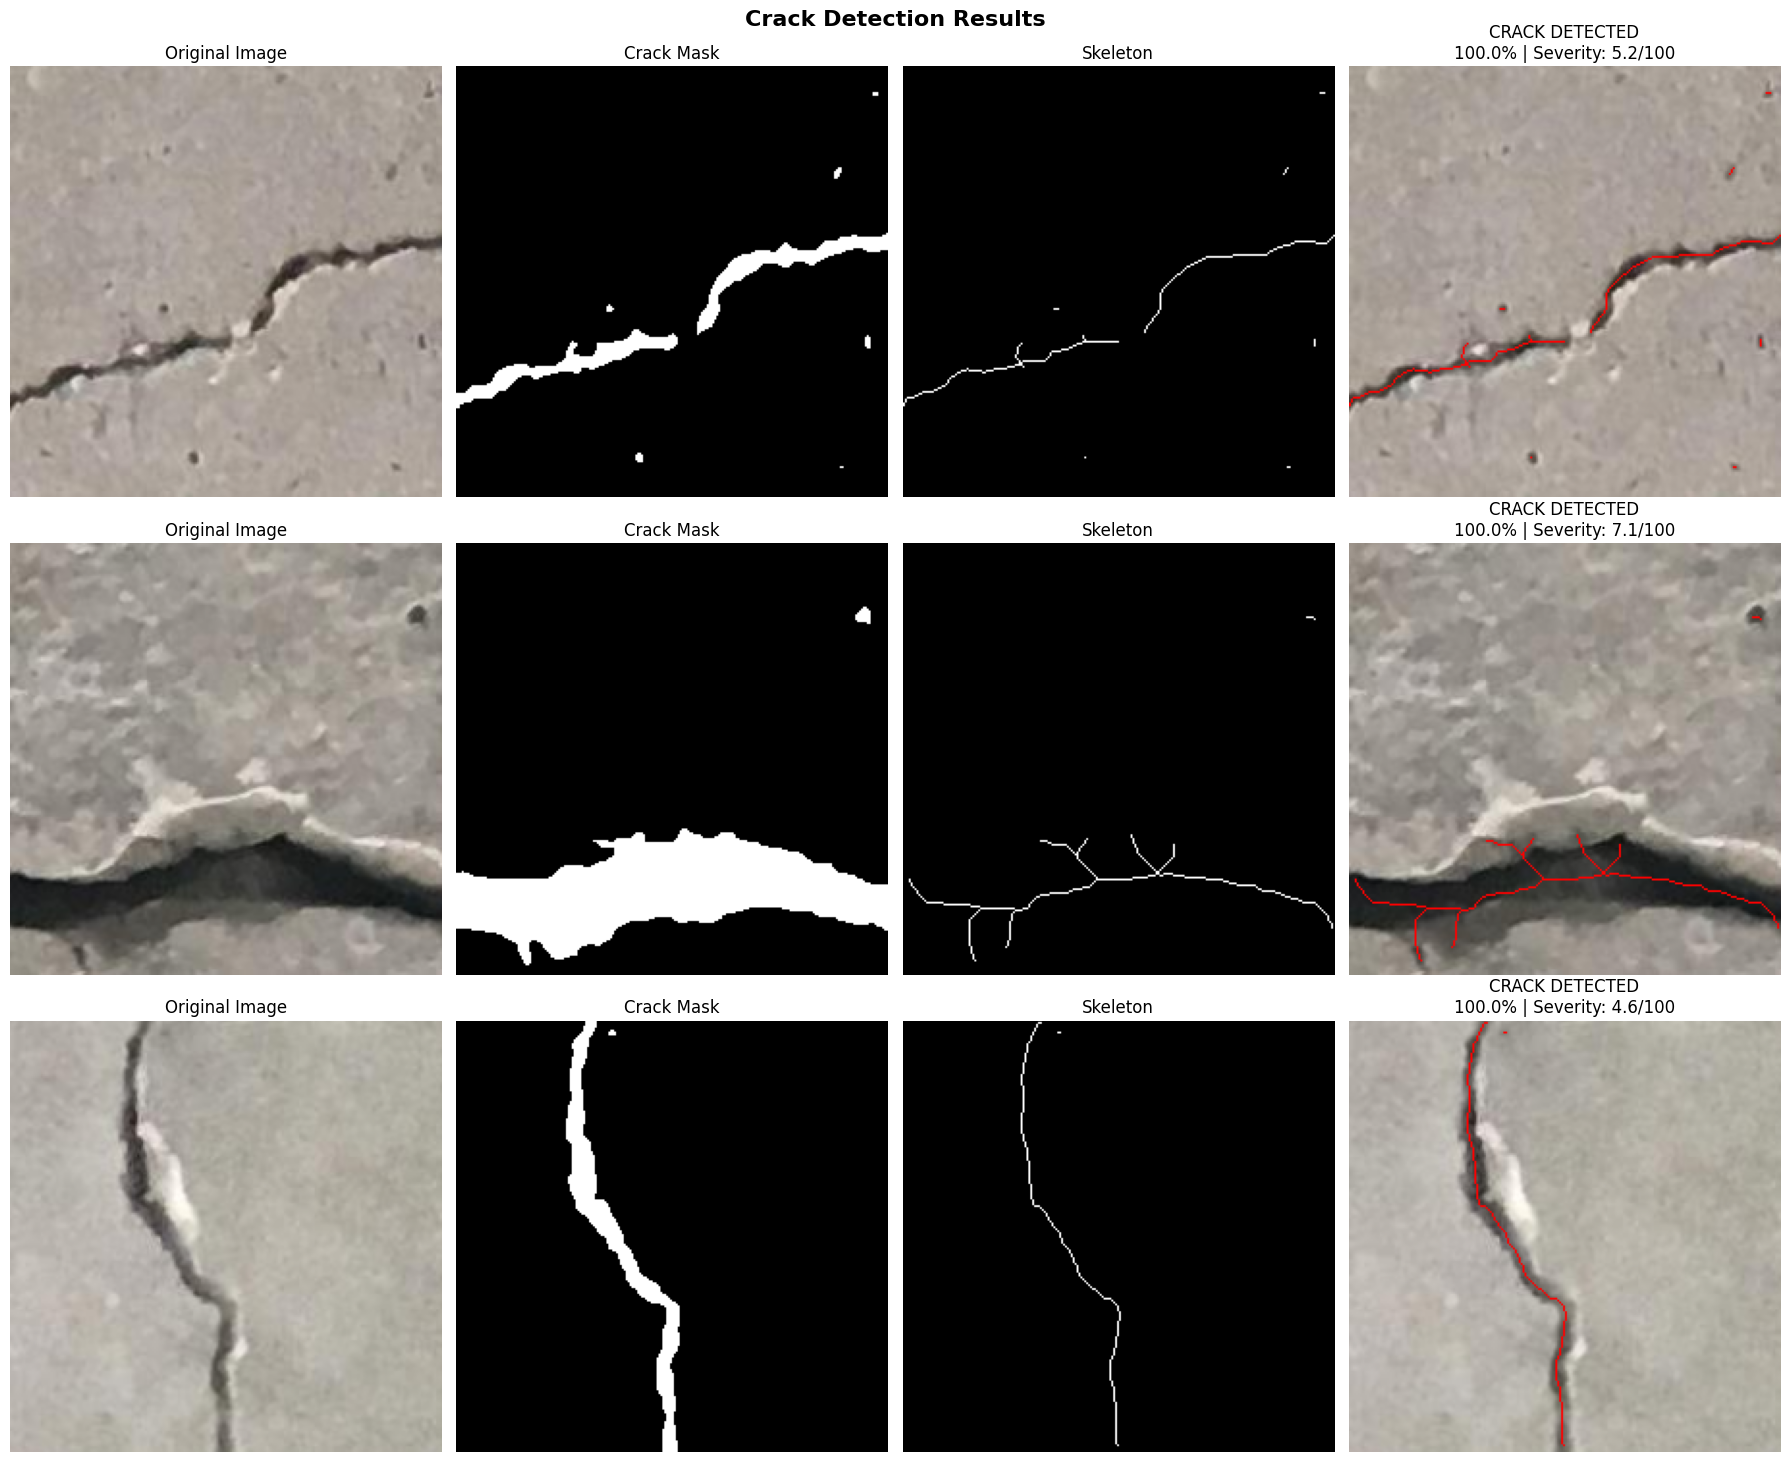

✅ Results saved!


In [15]:
import random

# Get random crack images
crack_images = [os.path.join('/kaggle/working/dataset/test/crack', f) 
                for f in os.listdir('/kaggle/working/dataset/test/crack')][:3]

fig, axes = plt.subplots(len(crack_images), 4, figsize=(18, 5*len(crack_images)))

for i, img_path in enumerate(crack_images):
    result = analyze_crack(img_path, best_model)
    
    axes[i][0].imshow(result['original'])
    axes[i][0].set_title('Original Image')
    axes[i][0].axis('off')
    
    if 'binary_mask' in result:
        axes[i][1].imshow(result['binary_mask'], cmap='gray')
        axes[i][1].set_title('Crack Mask')
        axes[i][1].axis('off')
        
        axes[i][2].imshow(result['skeleton'], cmap='gray')
        axes[i][2].set_title('Skeleton')
        axes[i][2].axis('off')
        
        overlay = result['original'].copy()
        overlay[result['skeleton']] = [255, 0, 0]
        axes[i][3].imshow(overlay)
        axes[i][3].set_title(f"{result['status']}\n{result['confidence']:.1%} | Severity: {result.get('severity', 0):.1f}/100")
        axes[i][3].axis('off')
    
    print(f'\n--- Image {i+1} ---')
    print(f'  Status     : {result["status"]}')
    print(f'  Confidence : {result["confidence"]:.2%}')
    if 'severity' in result:
        print(f'  Severity   : {result["severity"]:.1f}/100 ({result["severity_level"]})')
        print(f'  Urgency    : {result["urgency"]}')

plt.suptitle('Crack Detection Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/detection_results.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Results saved!')

## 🌐 STEP 12 — Gradio Web App

In [16]:
import gradio as gr

loaded_model = keras.models.load_model(MODEL_PATH)

def detect_crack(image):
    # Save temp image
    temp_path = '/kaggle/working/temp_input.jpg'
    Image.fromarray(image).save(temp_path)
    
    result = analyze_crack(temp_path, loaded_model)
    
    # Result image
    if 'skeleton' in result:
        overlay = result['original'].copy()
        overlay[result['skeleton']] = [255, 0, 0]
        result_img = overlay
    else:
        result_img = result['original']
    
    # Text output
    status_emoji = '⚠️' if result['status'] == 'CRACK DETECTED' else '✅'
    text = f"{status_emoji} {result['status']}\n"
    text += f"Confidence: {result['confidence']:.2%}\n"
    text += f"Inference Time: {result['infer_time']:.1f}ms\n"
    
    if 'severity' in result:
        text += f"\n📊 QUANTIFICATION\n"
        text += f"Severity: {result['severity']:.1f}/100 ({result['severity_level']})\n"
        text += f"Urgency: {result['urgency']}\n"
        text += f"\n🔧 REPAIR METHODS\n"
        for r in result['repair_methods']:
            text += f"• {r}\n"
        text += f"\n📋 STANDARDS: IS 456:2000, IS 13935:2009"
    
    return Image.fromarray(result_img), text

app = gr.Interface(
    fn=detect_crack,
    inputs=gr.Image(type='numpy', label='Upload Construction Image'),
    outputs=[
        gr.Image(label='Analysis Result'),
        gr.Textbox(label='Detection Report', lines=15)
    ],
    title='🏗️ Crack Detection & Maintenance System',
    description='Upload a concrete/wall image to detect cracks and get maintenance recommendations.',
    examples=[]
)

app.launch(share=True)
print('✅ Gradio app running!')

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://4f8a74ac99944d0285.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Gradio app running!


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

---
## 📌 Project Summary

| Component | Details |
|-----------|----------|
| **Model** | MobileNetV2 + Custom Head (Transfer Learning) |
| **Dataset** | Surface Crack Detection (~40,000 images) |
| **Platform** | Kaggle T4 GPU |
| **Output** | Crack detection + Severity + Repair recommendations |
| **Standards** | IS 456:2000, IS 13935:2009 |
| **GUI** | Gradio Web App |